# Classificacao de Cancer com Arvores de Decisao

Vamos classificar tumores em benignos ou malignos, baseado-se em diversos atributos destes.

## Imports, Carga de Dados, etc

#### Imports

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

#### Carga dos dados

**Breast Cancer Dataset**
http://scikit-learn.org/stable/datasets/index.html#datasets, section 5.14.

Colunas: mean, standard error, e "pior" valores para as 10 features abaixo, totalizando 30 features, seguidas da coluna com róótulos para as classes (malignant or benign).

* radius (mean of distances from center to points on the perimeter)
* texture (standard deviation of gray-scale values)
* perimeter
* area
* smoothness (local variation in radius lengths)
* compactness (perimeter^2 / area - 1.0)
* concavity (severity of concave portions of the contour)
* concave points (number of concave portions of the contour)
* symmetry
* fractal dimension (“coastline approximation” - 1)

In [2]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0,shuffle=True,stratify=y)

### Visualizando Árvores

#### Usando plot_tree()

tree.plot_tree(modelo)


[Text(0.675, 0.9285714285714286, 'x[27] <= 0.142\ngini = 0.468\nsamples = 455\nvalue = [170, 285]'),
 Text(0.45, 0.7857142857142857, 'x[23] <= 952.9\ngini = 0.156\nsamples = 304\nvalue = [26, 278]'),
 Text(0.25, 0.6428571428571429, 'x[13] <= 35.435\ngini = 0.067\nsamples = 286\nvalue = [10, 276]'),
 Text(0.1, 0.5, 'x[27] <= 0.132\ngini = 0.03\nsamples = 265\nvalue = [4, 261]'),
 Text(0.05, 0.35714285714285715, 'gini = 0.0\nsamples = 253\nvalue = [0, 253]'),
 Text(0.15, 0.35714285714285715, 'x[1] <= 21.34\ngini = 0.444\nsamples = 12\nvalue = [4, 8]'),
 Text(0.1, 0.21428571428571427, 'x[17] <= 0.01\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.05, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.15, 0.07142857142857142, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4, 0.5, 'x[19] <= 0.004\ngini = 0.408\nsamples = 21\nvalue = [6, 15]'),
 Text(0.35, 0.35714285714285715, 'x[27] 

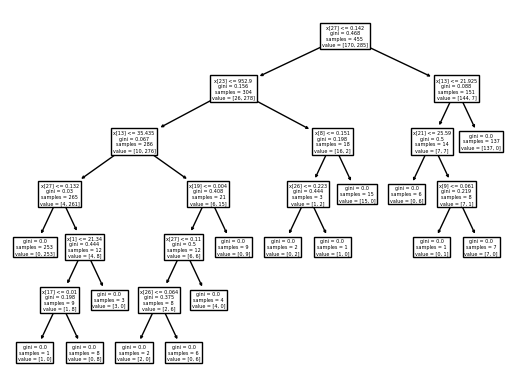

In [5]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train,y_train)
tree.plot_tree(clf)

#### Usando graphviz

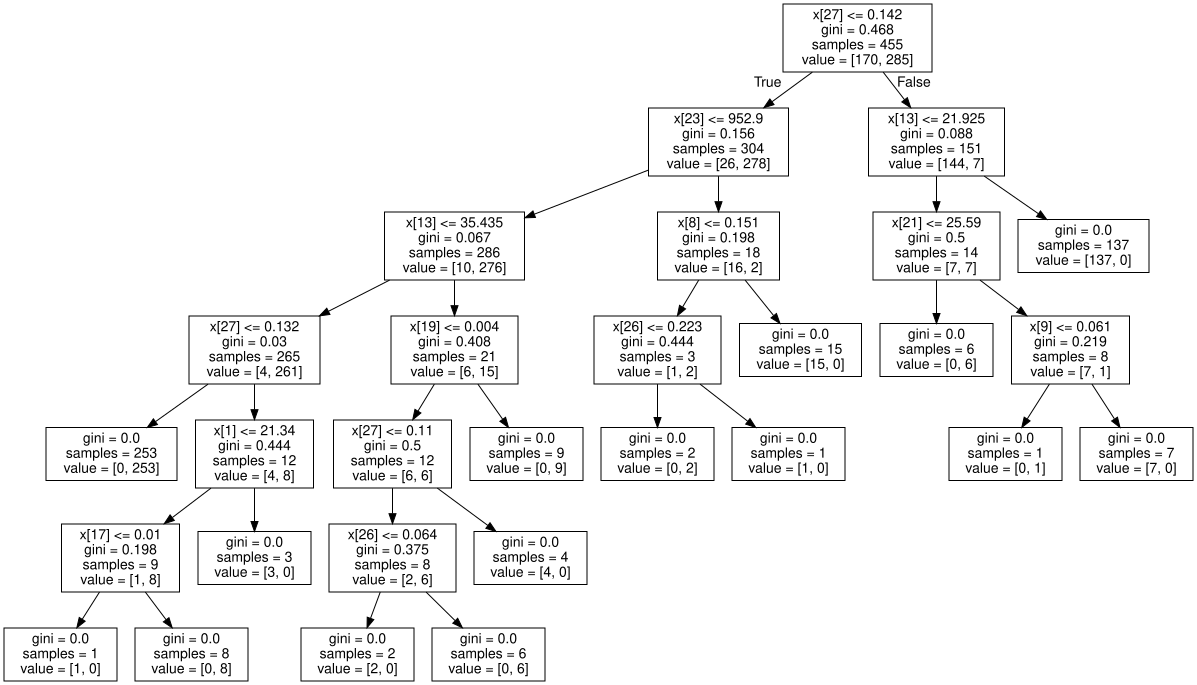

In [7]:
import graphviz

dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph

#### Usando graphviz (alterando estilo)

Alguns parâmetros: feature_names, class_names...

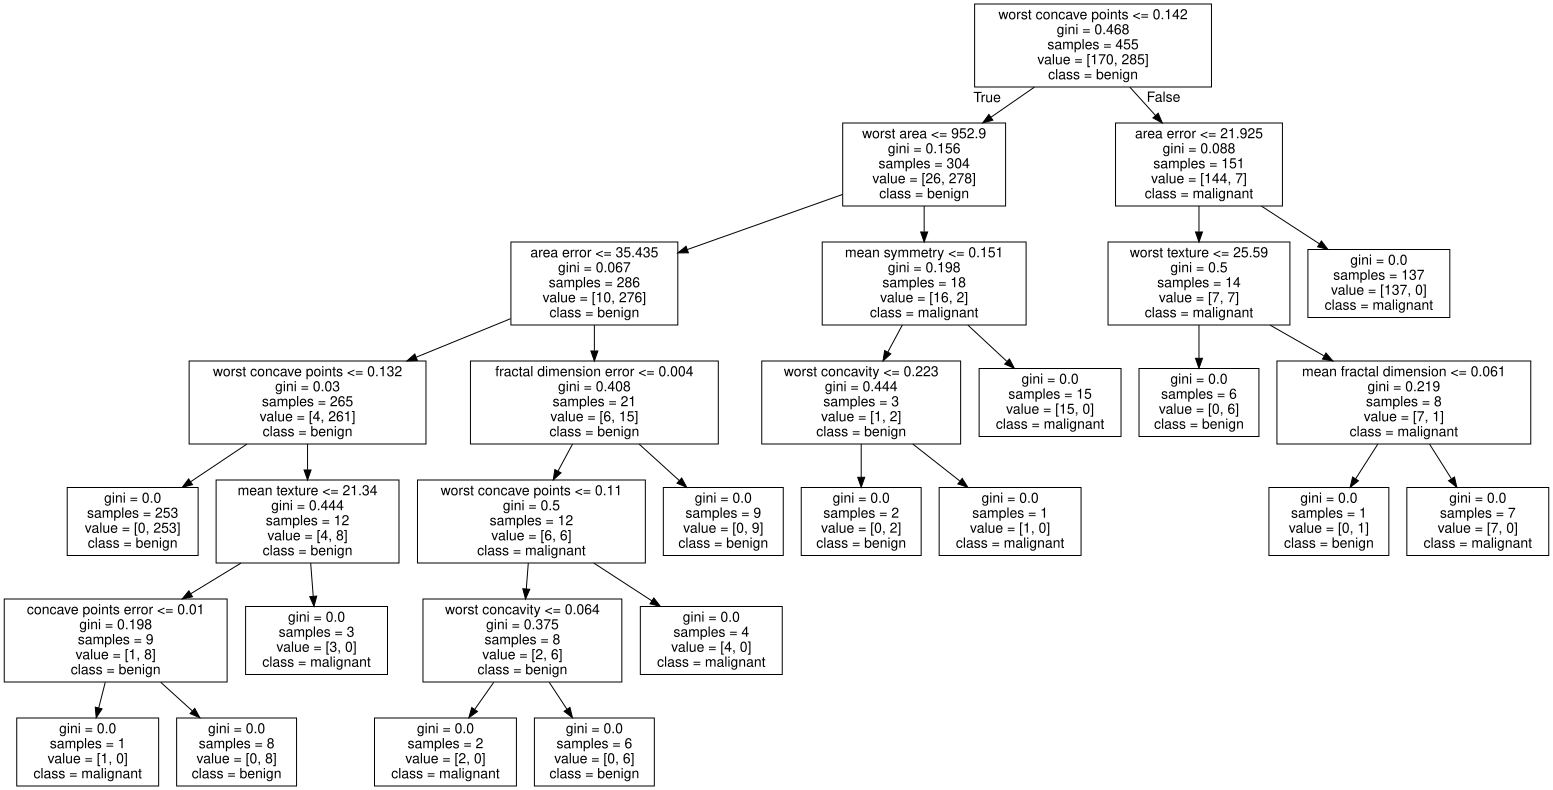

In [8]:
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=dataset.feature_names,class_names=dataset.target_names)
graph = graphviz.Source(dot_data)
graph

#### Visualizacao em formato textual (Exemplo 1)

tree.export_text(estimador, feature_names=)

In [9]:
print(tree.export_text(clf,feature_names=dataset.feature_names))

|--- worst concave points <= 0.14
|   |--- worst area <= 952.90
|   |   |--- area error <= 35.44
|   |   |   |--- worst concave points <= 0.13
|   |   |   |   |--- class: 1
|   |   |   |--- worst concave points >  0.13
|   |   |   |   |--- mean texture <= 21.34
|   |   |   |   |   |--- concave points error <= 0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- concave points error >  0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- mean texture >  21.34
|   |   |   |   |   |--- class: 0
|   |   |--- area error >  35.44
|   |   |   |--- fractal dimension error <= 0.00
|   |   |   |   |--- worst concave points <= 0.11
|   |   |   |   |   |--- worst concavity <= 0.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- worst concavity >  0.06
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- worst concave points >  0.11
|   |   |   |   |   |--- class: 0
|   |   |   |--- fractal dimension error >  0.00
|   |   |   |   |--- class: 1
|   |---

#### Visualizacao em formato textual (Exemplo 2)

Para entender como as regras separam os rótulos, também podemos imprimir o número de amostras de cada classe (pesos de classe / class wights) nas folhas.

Parametro show_weights

In [10]:
print(tree.export_text(clf,feature_names=dataset.feature_names,show_weights=True))


|--- worst concave points <= 0.14
|   |--- worst area <= 952.90
|   |   |--- area error <= 35.44
|   |   |   |--- worst concave points <= 0.13
|   |   |   |   |--- weights: [0.00, 253.00] class: 1
|   |   |   |--- worst concave points >  0.13
|   |   |   |   |--- mean texture <= 21.34
|   |   |   |   |   |--- concave points error <= 0.01
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- concave points error >  0.01
|   |   |   |   |   |   |--- weights: [0.00, 8.00] class: 1
|   |   |   |   |--- mean texture >  21.34
|   |   |   |   |   |--- weights: [3.00, 0.00] class: 0
|   |   |--- area error >  35.44
|   |   |   |--- fractal dimension error <= 0.00
|   |   |   |   |--- worst concave points <= 0.11
|   |   |   |   |   |--- worst concavity <= 0.06
|   |   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |   |   |   |--- worst concavity >  0.06
|   |   |   |   |   |   |--- weights: [0.00, 6.00] class: 1
|   |   |   |   |--- worst concave po

### Plotando uma Learning Curve

In [14]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(0.1,1,5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Exemplos de treinamento")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()


Chamando a funcao criada:

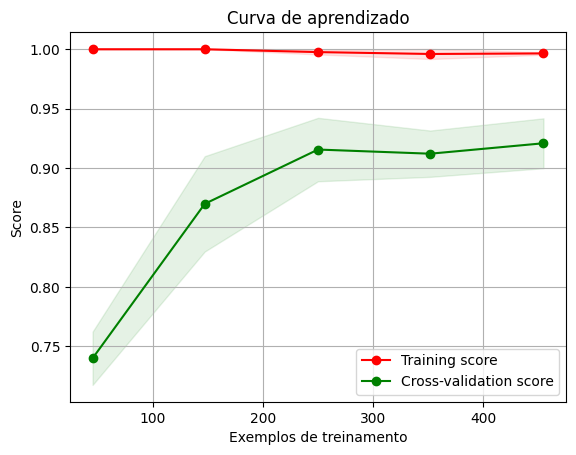

In [15]:
est = DecisionTreeClassifier(max_depth=6)

plot_learning_curve(est,"Curva de aprendizado",X,y)

### Plotando uma Validation Curve

In [21]:
def plot_validation_curve(param_range, train_scores, test_scores, title, param_name="Param Value", alpha=0.1):

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.ylim(0.0, 1.1)

    plt.plot(param_range, train_scores_mean, label="Training score", color="r")
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.2, color="r")
    plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                color="g")
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.2, color="g")
    plt.legend(loc="best")
    plt.show()


Chamando a funcao criada

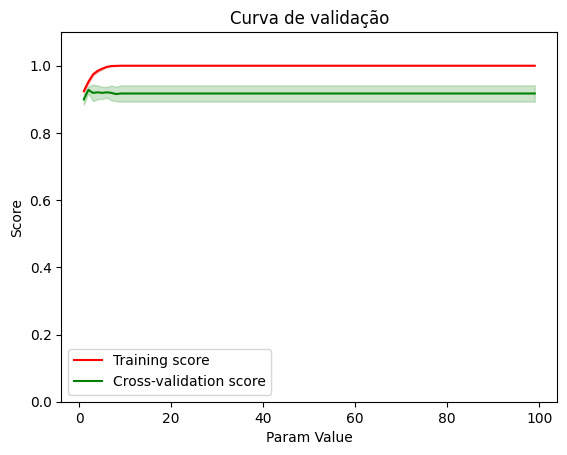

In [22]:
param_range = np.arange(1,100)
param_name = "max_depth"
est = DecisionTreeClassifier(random_state=42)

# Acrecentar a chamada a funcao validation_curve completando o codigo a seguir (usar scoring="accuracy")
train_scores, test_scores = validation_curve(estimator=est,X=X,y=y,scoring='accuracy',param_name=param_name, param_range=param_range)
plot_validation_curve(param_range,train_scores,test_scores,"Curva de validação")
